# Build A Backpropagation algorithm from Scartch

# Import Libraries

In [ ]:
import random

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.optimizers import SGD

# Make Custom Dataset

In [ ]:
data = {
    "CGPA": [3.12, 2.83, 3.45, 3.99, 2.66, 3.78, 3.41, 2.55, 3.89, 3.14]*2,
    "Score": [random.randrange(5, 11) for _ in range(20)],
    "Package_LPA": [round(random.uniform(3.0, 15.0), 2) for _ in range(20)]
}

In [ ]:
df = pd.DataFrame(data=data)
df.head()

,CGPA,Score,Package_LPA
0,3.12,7,3.77
1,2.83,7,3.38
2,3.45,6,3.74
3,3.99,5,11.12
4,2.66,9,7.92


## Plot Data

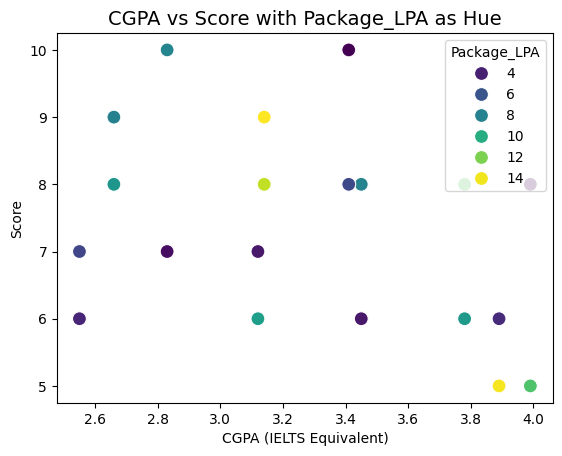

In [ ]:
sns.scatterplot(data=df, x='CGPA', y='Score', hue='Package_LPA', palette='viridis', s=100)
plt.title('CGPA vs Score with Package_LPA as Hue', fontsize=14)
plt.xlabel('CGPA (IELTS Equivalent)')
plt.ylabel('Score')
plt.show()

# Separare X, y

In [ ]:
X = df.drop(['Package_LPA'], axis=1)
y = df['Package_LPA']
X.values[0]

array([3.12, 7.  ])

# Create New Dataset

In [ ]:
X, y = make_regression(n_samples=1000000, n_features=2, n_informative=1)

## Plot New Dataset

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


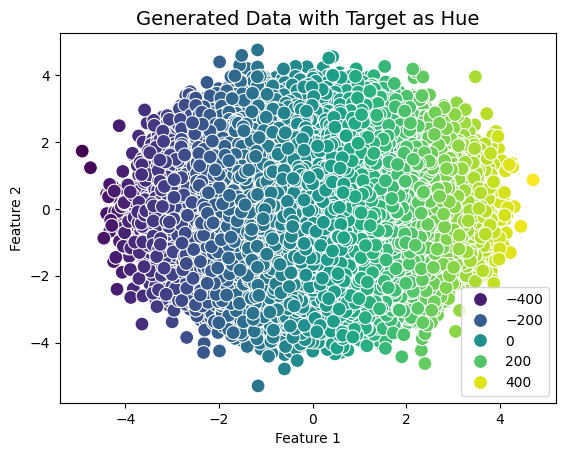

In [ ]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', s=100)
plt.title('Generated Data with Target as Hue', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# My Custom Backpropagation Algorithm

In [ ]:
class MyBackpropagation:
  def __init__(self, lr=0.1, epochs=5) -> None:
    self.lr = lr
    self.epochs = epochs
    self.weights_ = []
    self.bias_ = []
    self.mse_loss = []
    self.epochs_loss = []

    self._init_weights = []
    self._init_bias = []

  def forward_propagation(self, X, y):

    # Hidden Layer
    O11 = self.weights_[0]*X[0] + self.weights_[2]*X[1] + self.bias_[0]
    O12 = self.weights_[1]*X[0] + self.weights_[3]*X[1] + self.bias_[1]

    # Output Layer
    O21 = self.weights_[4]*O11 + self.weights_[5]*O12 + self.bias_[2]
    # print(f'O11: {O11:.4f}, O12: {O12:.4f}, O21 (output): {O21:.4f}\n')

    return O11, O12, O21

  def update_parameters(self, X, y, O21, O11, O12):
    y_hat = O21
    dO21 = -2*(y-y_hat)
    dO11 = self.weights_[4]*dO21
    dO12 = self.weights_[5]*dO21


    # Calculate for Y_hat or O21
    self.weights_[4] = self.weights_[4]  - self.lr * dO21 * O11
    self.weights_[5] = self.weights_[5]  - self.lr * dO21 * O12
    self.bias_[2] = self.bias_[2] - self.lr * dO21

    # Calculate for O11
    self.weights_[0] = self.weights_[0]  - self.lr * dO11 * X[0]
    self.weights_[2] = self.weights_[2]  - self.lr * dO11 * X[1]
    self.bias_[0] = self.bias_[0] - self.lr * dO11

    # Calculate for O12
    self.weights_[1] = self.weights_[1]  - self.lr * dO12 * X[0]
    self.weights_[3] = self.weights_[3]  - self.lr * dO12 * X[1]
    self.bias_[1] = self.bias_[1] - self.lr * dO12



  def fit(self, X, y):
    self.weights_ = np.array([random.random() for _ in range(6)])
    self.bias_ = np.array([random.random() for _ in range(3)])

    self._init_weights = self.weights_.copy()
    self._init_bias = self.bias_.copy()

    for _ in range(self.epochs):
      for __ in range(X.shape[0]):

        index = random.randint(0, X.shape[0]-1)
        O11, O12, O21 = self.forward_propagation(X[index], y)
        # print(f'Data for index = {index}, prediction = {y_hat}, actual_data = {y[index]}')

        self.mse_loss.append((y[index] - O21)**2)

        # Update Weight and Bias
        self.update_parameters(X[index], y[index], O21, O11, O12)

      self.epochs_loss.append(np.mean(self.mse_loss))
      print(f'epochs {_}/{self.epochs}, loss = {self.epochs_loss[_]}')
      self.mse_loss.clear()


  def get_weights(self, type: str = 'updated'):
      # Select which set of weights to return
      if type == 'init':
          w = self._init_weights
          b = self._init_bias
      else:
          w = self.weights_
          b = self.bias_

      # Map to Keras format
      return [
          np.array([[w[0], w[1]],      # dense_4 kernel (2x2)
                    [w[2], w[3]]]),
          np.array([b[0], b[1]]),      # dense_4 bias (2,)
          np.array([[w[4]],            # dense_5 kernel (2x1)
                    [w[5]]]),
          np.array([b[2]])             # dense_5 bias (1,)
      ]

## Scale Dataset

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Fit Model

In [ ]:
my_model = MyBackpropagation(lr=0.001, epochs=10)
my_model.fit(X_scaled, y)

epochs 0/10, loss = 0.13324548902856312
epochs 1/10, loss = 6.214090906866828e-28
epochs 2/10, loss = 6.503464941709336e-28
epochs 3/10, loss = 6.203826608666577e-28
epochs 4/10, loss = 6.316278591224895e-28
epochs 5/10, loss = 6.151308438135126e-28
epochs 6/10, loss = 6.333969084518014e-28
epochs 7/10, loss = 6.239739379552747e-28
epochs 8/10, loss = 6.293820935556047e-28
epochs 9/10, loss = 6.278447514382409e-28


## Initials Weights and Bias

In [ ]:
my_model.get_weights(type='init')

[array([[0.4532102 , 0.58898586],
        [0.44375135, 0.29375398]]),
 array([0.96908387, 0.27682824]),
 array([[0.63654075],
        [0.67609076]]),
 array([0.79530076])]

## Updated weight and bias

In [ ]:
my_model.get_weights(type='updated')

[array([[ 6.3651086 ,  7.90656733],
        [ 0.11576483, -0.09356766]]),
 array([ 0.29673062, -0.30630455]),
 array([[5.8916605 ],
        [7.28934584]]),
 array([0.57249215])]

# Keras Library

In [ ]:
keras_model = Sequential(name="keras-model")
keras_model.add(Input(shape=(X_scaled.shape[1], )))
keras_model.add(Dense(units=2))
keras_model.add(Dense(units=1))


In [ ]:
keras_model.summary()

Model: "keras-model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

## Set weights and bias

In [ ]:
keras_model.get_weights()

[array([[-0.70001626, -0.1351496 ],
        [ 0.32557452, -0.20437825]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.7284894 ],
        [-0.15925574]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
for layer in keras_model.layers:
    print(layer.name, layer.get_weights()[0].shape, layer.get_weights()[1].shape)

dense_8 (2, 2) (2,)
dense_9 (2, 1) (1,)


In [ ]:
new_weight = [
    np.array([my_model._init_weights[0:2].tolist(), my_model._init_weights[2:4].tolist()]),
    np.array(my_model._init_bias[:2].tolist()),
    np.array([[my_model._init_weights[4].tolist()], [my_model._init_weights[5].tolist()]]),
    np.array([my_model._init_bias[2].tolist()])
]
keras_model.set_weights(new_weight)

In [ ]:
keras_model.get_weights()

[array([[0.4532102 , 0.58898586],
        [0.44375136, 0.29375398]], dtype=float32),
 array([0.96908385, 0.27682823], dtype=float32),
 array([[0.6365408],
        [0.6760908]], dtype=float32),
 array([0.7953008], dtype=float32)]

In [ ]:
optimizer = SGD(learning_rate=0.001)
keras_model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mse']
)

In [ ]:
keras_model.fit(x=X_scaled, y=y, epochs=10)

Epoch 1/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 28s 883us/step - loss: 29.3897 - mse: 29.3897
Epoch 2/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 27s 873us/step - loss: 4.6522e-11 - mse: 4.6522e-11
Epoch 3/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 28s 885us/step - loss: 4.5875e-11 - mse: 4.5875e-11
Epoch 4/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 27s 875us/step - loss: 4.8605e-11 - mse: 4.8605e-11
Epoch 5/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 28s 891us/step - loss: 4.4659e-11 - mse: 4.4659e-11
Epoch 6/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 27s 875us/step - loss: 4.6491e-11 - mse: 4.6491e-11
Epoch 7/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 28s 887us/step - loss: 3.6684e-11 - mse: 3.6684e-11
Epoch 8/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 28s 880us/step - loss: 3.6350e-11 - mse: 3.6350e-11
Epoch 9/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 27s 875us/step - loss: 3.6082e-11 - mse: 3.6082e-11
Epoch 10/10
31250/31250 ━━━━━━━━━━━━━━━━━━━━ 28s 890us/step - loss: 3.6187e-11 - mse: 3.6187e-11


# Keras vs Custom Updated Weight

In [ ]:
keras_model.get_weights()

[array([[ 6.3245564 ,  7.466737  ],
        [ 0.11287767, -0.09455709]], dtype=float32),
 array([ 0.38633206, -0.40500686], dtype=float32),
 array([[6.2432656],
        [7.4529047]], dtype=float32),
 array([0.6944701], dtype=float32)]

In [ ]:
my_model.get_weights(type='updated')

[array([[ 6.3651086 ,  7.90656733],
        [ 0.11576483, -0.09356766]]),
 array([ 0.29673062, -0.30630455]),
 array([[5.8916605 ],
        [7.28934584]]),
 array([0.57249215])]